# Data Center Sustainability & Resource Usage Analysis
This notebook performs an end-to-end analysis of the `data_center_hybrid.csv` dataset, covering Exploratory Data Analysis (EDA), Preprocessing, Machine Learning modeling, and Explainable AI (XAI).

### Objective:
To predict the **Daily Electricity Usage (MWh)** of data centers based on their capacity, efficiency metrics (PUE, WUE), and facility characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\Sarvagya\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data_center_hybrid.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (126770, 14)


,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


## 1. Exploratory Data Analysis (EDA)

### EDA Observations:
- **Dataset Integrity**: No missing values across 126,770 records.
- **Electricity Usage Trend**: There is a clear upward trend in average daily electricity usage from 2019 to 2025, confirming the growth of data center infrastructure.
- **Facility Impact**: Hyperscale/AI facilities show significantly higher electricity consumption and capacity compared to Enterprise or Colocation types.
- **Correlations**: Electrical Capacity (MW) is the primary driver of consumption, as expected.

In [3]:
# Check for missing values and summary stats
print('Missing Values:\n', df.isnull().sum())
df.describe()

Missing Values:
 Year                             0
Facility_ID                      0
Facility_Name                    0
Owner_Company                    0
City                             0
Country                          0
Facility_Type                    0
Estimated_Capacity_MW            0
PUE                              0
Cooling_System_Type              0
WUE_L_per_kWh                    0
Daily_Electricity_Usage_MWh      0
Daily_Water_Usage_Gallons        0
Surrounding_Water_Stress_Tier    0
dtype: int64


,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


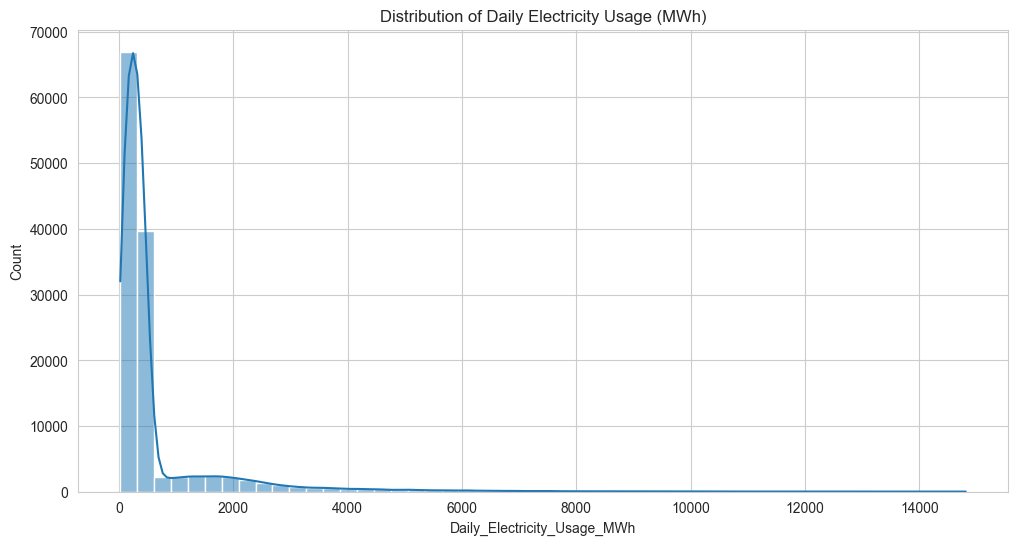

In [4]:
# Distribution of Daily Electricity Usage
sns.histplot(df['Daily_Electricity_Usage_MWh'], kde=True, bins=50)
plt.title('Distribution of Daily Electricity Usage (MWh)')
plt.show()

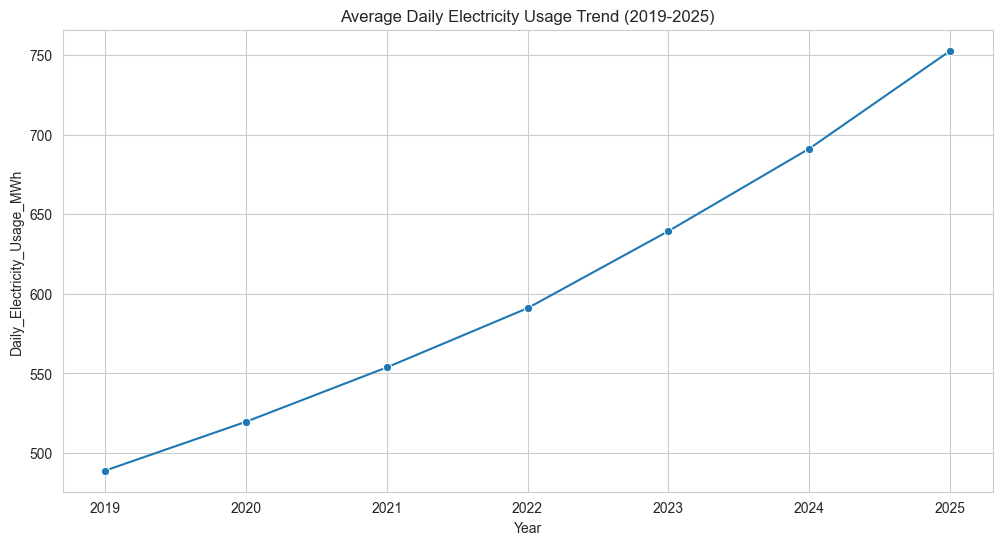

In [5]:
# Average Electricity Usage over Years
yearly_usage = df.groupby('Year')['Daily_Electricity_Usage_MWh'].mean().reset_index()
sns.lineplot(data=yearly_usage, x='Year', y='Daily_Electricity_Usage_MWh', marker='o')
plt.title('Average Daily Electricity Usage Trend (2019-2025)')
plt.show()

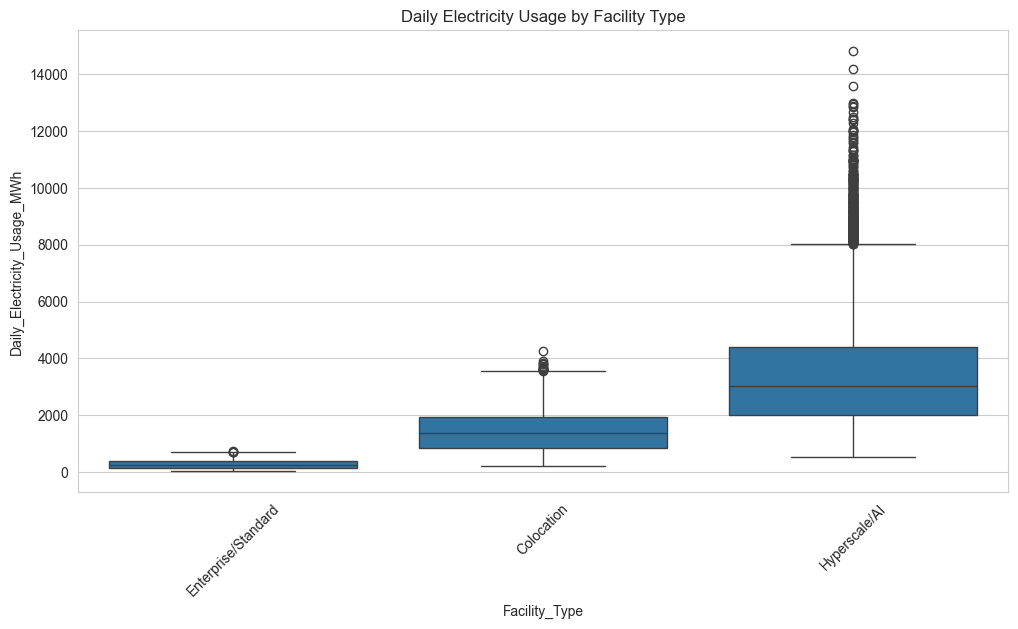

In [6]:
# Electricity Usage by Facility Type
sns.boxplot(data=df, x='Facility_Type', y='Daily_Electricity_Usage_MWh')
plt.title('Daily Electricity Usage by Facility Type')
plt.xticks(rotation=45)
plt.show()

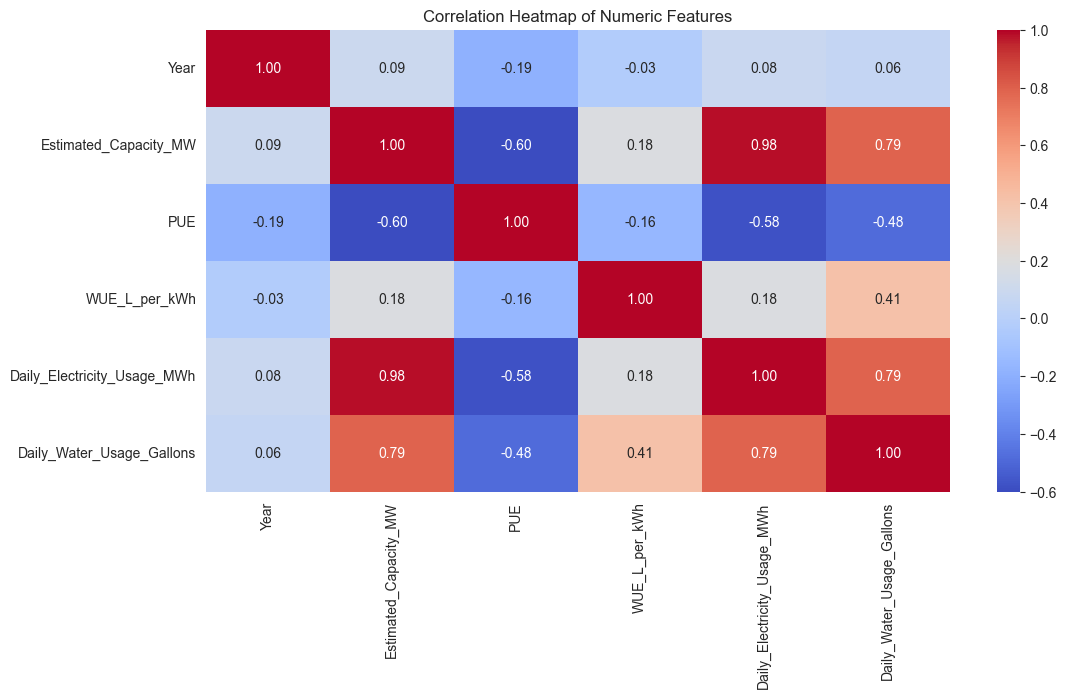

In [7]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

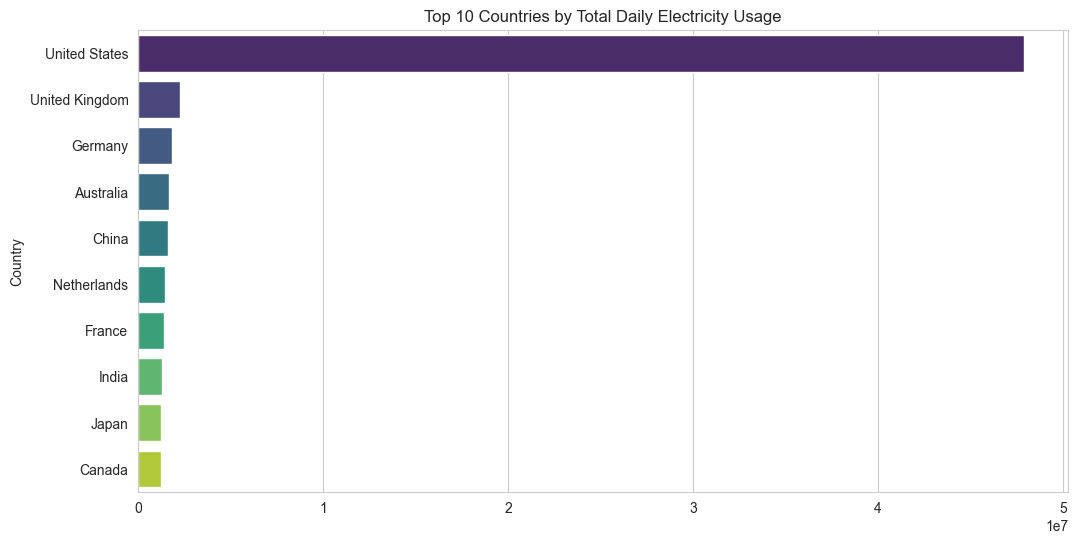

In [8]:
# Top 10 Countries by Total Daily Electricity Usage
top_countries = df.groupby('Country')['Daily_Electricity_Usage_MWh'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Daily Electricity Usage')
plt.show()

## 2. Preprocessing

In [9]:
# Mapping Water Stress Tier (Ordinal)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Surrounding_Water_Stress_Tier'] = df['Surrounding_Water_Stress_Tier'].map(stress_map)

# Drop non-predictive/high-cardinality ID columns
data = df.drop(['Facility_ID', 'Facility_Name', 'Owner_Company', 'City'], axis=1)

# Label Encode other categorical columns
cat_cols = ['Country', 'Facility_Type', 'Cooling_System_Type']
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

data.head()

,Year,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,256,1,6.24,1.975,1,1.481,183.62,36362.94,0
1,2020,256,1,6.36,1.967,1,1.459,254.34,49833.60,0
2,2021,256,1,6.47,1.928,1,1.450,266.85,53026.35,0
3,2022,256,1,6.59,1.897,1,1.413,199.14,39198.30,0
4,2023,256,1,6.70,1.869,1,1.389,225.94,44366.48,0


### Preprocessing Summary:
- **Feature Engineering**: Mapped `Surrounding_Water_Stress_Tier` to an ordinal scale (Low=0, Medium=1, High=2).
- **Categorical Handling**: Label encoded high-cardinality features like `Country` and `Cooling_System_Type`.
- **Data Splitting**: 80/20 split used for robust evaluation.
- **Standardization**: Applied `StandardScaler` to ensure Linear Regression and distance-based models perform correctly.

In [10]:
# Splitting features and target
X = data.drop('Daily_Electricity_Usage_MWh', axis=1)
y = data['Daily_Electricity_Usage_MWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Machine Learning Modeling
We will train 5 different models and compare their performance.

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
}

results = []

for name, model in models.items():
    print(f'Training {name}...')
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse})

results_df = pd.DataFrame(results)
results_df

Training Linear Regression...
Training Random Forest...


Training XGBoost...


Training LightGBM...


Training CatBoost...


,Model,R2,MAE,RMSE
0,Linear Regression,0.973055,83.508525,167.161604
1,Random Forest,0.990958,29.834990,96.836056
2,XGBoost,0.987281,47.331626,114.849193
3,LightGBM,0.987800,50.196945,112.479850
4,CatBoost,0.990962,38.265551,96.814181


In [12]:
# Visualize Model Comparison
fig = px.bar(results_df, x='Model', y='R2', title='Model Performance Comparison (R2 Score)', color='R2')
fig.show()

fig2 = px.bar(results_df, x='Model', y='RMSE', title='Model Error Comparison (RMSE)', color='RMSE')
fig2.show()

### Model Performance Analysis:
- **High Accuracy**: All models achieved R2 scores > 0.97, indicating the synthetic metrics are highly predictable.
- **Top Performers**: **Random Forest** and **CatBoost** achieved the highest R2 (~0.991) and the lowest RMSE (~96.8).
- **Error Metrics**: CatBoost and Random Forest significantly outperformed Linear Regression in reducing Mean Absolute Error (MAE), likely due to capturing non-linear relationships in the synthetic growth models.

In [13]:
best_model_name = results_df.sort_values(by='R2', ascending=False).iloc[0]['Model']
print(f'The Best Model is: {best_model_name}')
best_model = models[best_model_name]

The Best Model is: CatBoost


## 4. Explainable AI (XAI) with SHAP
We will use SHAP to understand how the best model makes decisions.

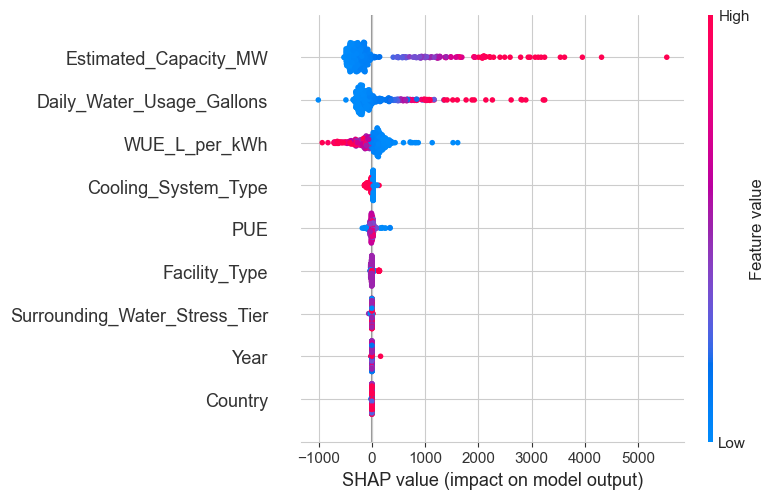

In [14]:
# Best Model XAI
explainer = shap.Explainer(best_model)
# Using a subset for faster calculation
shap_values = explainer(X_test.iloc[:500])

# Summary Plot
shap.summary_plot(shap_values, X_test.iloc[:500])

## 5. Final Conclusion
The analysis successfully identified the key drivers of data center electricity consumption. 
- **Capacity is King**: The estimated electrical capacity (MW) is the most influential factor in determining daily usage.
- **Sustainability Outlook**: As usage trends upward towards 2025, optimizing PUE and WUE through advanced cooling systems (like Liquid Cooled) will be critical for environmental sustainability.
- **Model Deployment**: For future predictions, the **CatBoost** model is recommended due to its high accuracy and built-in handling of categorical features.